In [35]:
import pysmile_license
import pysmile
import numpy as np
import random
import csv
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from EDAspy.optimization import UMDAc, EGNA, EMNA

In [36]:
class IDRecovery:
    def __init__(self, xdsl_path, rules_csv, min_max_ut=False, u_range=(0, 10), save_plots=False,
                 chance_init_bounds=(-5, 5), utility_init_bounds=(-10, 10),
                 alpha=0.5, elite_factor=0.0, n_decision_rules=-1, 
                 fitness_type='regret', stop_mode='best', optimizer_type='umda'):

        self.net = pysmile.Network()
        self.net.read_file(xdsl_path)
        self.u_min, self.u_max = u_range
        self.min_max_ut = min_max_ut 
        self.alpha = alpha
        self.elite_factor = elite_factor
        self.n_decision_rules = n_decision_rules
        self.fitness_type = fitness_type 
        self.stop_mode = stop_mode
        self.optimizer_type = optimizer_type.lower()
        
        self.chance_init_bounds = chance_init_bounds
        self.utility_init_bounds = utility_init_bounds

        self.chance_nodes = self._get_nodes(["CPT", "TRUTHTABLE"])
        self.utility_nodes = self._get_nodes(["UTILITY"])
        
        self.original_defs = {
            name: np.array(self.net.get_node_definition(self.net.get_node(name))) 
            for name in self.chance_nodes + self.utility_nodes
        }

        self.specs = self._build_specs()
        self.total_vars = sum(s['free_size'] for s in self.specs)
        
        self.all_rules = self._compile_rules(rules_csv)
        
        random.seed(42)
        if self.n_decision_rules > 0 and self.n_decision_rules < len(self.all_rules):
            self.train_rules = random.sample(self.all_rules, self.n_decision_rules)
        else:
            self.train_rules = self.all_rules
            
        print(f"Optimizador: {self.optimizer_type.upper()}")
        print(f"Modo de Fitness: {self.fitness_type.upper()}")
        print(f"Reglas totales para evaluar precisión: {len(self.all_rules)}")
        print(f"Reglas usadas para entrenar (Fitness): {len(self.train_rules)}")
        
        self.eval_count = 0
        self.current_gen = 1
        
        self.gen_individuals = []
        self.gen_fitness = []
        self.gen_errors = []
        self.gen_accuracies = [] 
        
        self.history = []

    def _get_nodes(self, types):
        valid = [getattr(pysmile.NodeType, t) for t in types if hasattr(pysmile.NodeType, t)]
        return [self.net.get_node_id(h) for h in self.net.get_all_nodes() if self.net.get_node_type(h) in valid]

    def _build_specs(self):
        specs = []
        for name in self.chance_nodes + self.utility_nodes:
            h = self.net.get_node(name)
            size = len(self.net.get_node_definition(h))
            kind = 'chance' if name in self.chance_nodes else 'utility'
            parents = self.net.get_parents(h)
            shape = tuple([self.net.get_outcome_count(p) for p in parents]) + ((self.net.get_outcome_count(h),) if kind == 'chance' else ())

            mask = np.ones(size, dtype=bool)
            fixed = []
            
            if kind == 'utility' and self.min_max_ut:
                original_u = self.original_defs[name]
                best_flat = np.argmax(original_u)
                worst_flat = np.argmin(original_u)
                best_idx = np.unravel_index(best_flat, shape)
                worst_idx = np.unravel_index(worst_flat, shape)
                
                fixed.append((best_idx, self.u_max))
                mask[best_flat] = False
                
                if worst_flat != best_flat:
                    fixed.append((worst_idx, self.u_min))
                    mask[worst_flat] = False
            
            specs.append({'name': name, 'kind': kind, 'size': size, 'free_size': mask.sum(), 'shape': shape, 'mask': mask, 'fixed': fixed})
        return specs

    def _compile_rules(self, path):
        compiled = []
        with open(path, 'r') as f:
            for row in csv.DictReader(f):
                ev = {k: int(v) - 1 for k, v in row.items() if int(v or 0) > 0}
                target = next(k for k, v in row.items() if int(v or 0) < 0)
                act_idx = abs(int(row[target])) - 1
                h = self.net.get_node(target)
                mult, c_idx = 1, 0
                for p in reversed(self.net.get_parents(h)):
                    c_idx += ev[self.net.get_node_id(p)] * mult
                    mult *= self.net.get_outcome_count(p)
                compiled.append({'node': target, 'c_idx': c_idx, 'a_idx': act_idx, 'n_act': self.net.get_outcome_count(h)})
        return compiled

    def _decode_vector(self, vector):
        pos = 0
        real_error = 0
        decoded_vals = {}
        
        for s in self.specs:
            raw = vector[pos:pos+s['free_size']]
            pos += s['free_size']
            
            if s['kind'] == 'chance':
                res = np.exp(raw.reshape(s['shape']))
                val = (res / res.sum(axis=-1, keepdims=True)).flatten()
            else:
                val = np.zeros(s['size'])
                val[s['mask']] = (1 / (1 + np.exp(-raw))) * (self.u_max - self.u_min) + self.u_min
                for idx, fv in s['fixed']: 
                    val[np.ravel_multi_index(idx, s['shape'])] = fv

            decoded_vals[s['name']] = val
            real_error += np.mean((val - self.original_defs[s['name']])**2)
            
        return decoded_vals, real_error

    def fitness(self, vector):
        decoded_vals, real_error = self._decode_vector(vector)
        
        for name, val in decoded_vals.items():
            self.net.set_node_definition(name, val.tolist()) 
        
        try: 
            self.net.update_beliefs()
        except pysmile.SMILEException: 
            return 1e6
        
        penalty_score = 0 
        
        # 1. EVALUAR FITNESS (Entrenamiento)
        for r in self.train_rules:
            try:
                utils = self.net.get_node_value(r['node'])[r['c_idx']*r['n_act'] : (r['c_idx']+1)*r['n_act']]
                max_u = max(utils)
                rule_u = utils[r['a_idx']]
                
                if self.fitness_type == 'binary':
                    if (max_u - rule_u) > 0:
                        penalty_score += 1
                        
                elif self.fitness_type == 'regret':
                    penalty_score += (max_u - rule_u)
                    
                elif self.fitness_type == 'margin':
                    margen = 1.0 
                    utilidades_alternativas = [u for i, u in enumerate(utils) if i != r['a_idx']]
                    mejor_alternativa = max(utilidades_alternativas) if utilidades_alternativas else 0
                    penalty_score += max(0, (mejor_alternativa + margen) - rule_u)
                    
                elif self.fitness_type == 'softmax':
                    exp_utils = np.exp(np.array(utils) - max_u) 
                    prob_rule = exp_utils[r['a_idx']] / np.sum(exp_utils)
                    penalty_score += -np.log(prob_rule + 1e-9) 
                    
                elif self.fitness_type == 'regret_reg':
                    penalty_score += (max_u - rule_u)
                    
            except IndexError:
                return 1e6

        # --- APLICAR REGULARIZACIÓN CIEGA ---
        if self.fitness_type == 'regret_reg':
            lambda_reg = 0.01 
            l2_penalty = np.sum(vector**2)
            penalty_score += (lambda_reg * l2_penalty)
                
        # --- RASTREO DEL MEJOR HISTÓRICO ---
        if hasattr(self, 'best_historical_fitness') and penalty_score < self.best_historical_fitness:
            self.best_historical_fitness = penalty_score
            self.best_historical_ind = vector
            
        # 2. EVALUAR PRECISIÓN GLOBAL (Test/Gráficas)
        rules_fulfilled = 0
        for r in self.all_rules:
            try:
                utils = self.net.get_node_value(r['node'])[r['c_idx']*r['n_act'] : (r['c_idx']+1)*r['n_act']]
                if (max(utils) - utils[r['a_idx']]) <= 1e-5:
                    rules_fulfilled += 1
            except IndexError:
                return 1e6
                
        accuracy = (rules_fulfilled / len(self.all_rules)) * 100
            
        self.gen_individuals.append(vector)
        self.gen_fitness.append(penalty_score) 
        self.gen_errors.append(real_error)
        self.gen_accuracies.append(accuracy)
        self.eval_count += 1
        
        # --- FINAL DE GENERACIÓN ---
        if hasattr(self, 'size_gen') and self.eval_count % self.size_gen == 0:
            
            self.history.append({
                'gen': self.current_gen,
                'errors': np.array(self.gen_errors),
                'fitness': np.array(self.gen_fitness),
                'accuracies': np.array(self.gen_accuracies)
            })
            
            sorted_fitness = np.sort(self.gen_fitness)
            
            if self.stop_mode == 'top10':
                target_idx = max(1, int(self.size_gen * 0.10)) - 1
                msg_parada = f"El Top 10% (≥{target_idx+1} individuos) alcanzó"
            elif self.stop_mode == 'top30':
                target_idx = max(1, int(self.size_gen * 0.30)) - 1
                msg_parada = f"El Top 30% (≥{target_idx+1} individuos) alcanzó"
            else:
                target_idx = 0
                msg_parada = "El mejor individuo absoluto alcanzó"
                
            value_to_check = sorted_fitness[target_idx]
            
            self.current_gen += 1
            self.gen_individuals, self.gen_fitness, self.gen_errors, self.gen_accuracies = [], [], [], []
            
            if hasattr(self, 'target_fitness') and value_to_check <= self.target_fitness:
                raise StopIteration(f"{msg_parada} un Score ≤ {self.target_fitness}")
            
        return penalty_score

    def run(self, g=100, i=100, target_fitness=1e-5):
        self.size_gen = g
        self.target_fitness = 0.0 if self.fitness_type == 'binary' else target_fitness
        
        self.best_historical_ind = None
        self.best_historical_fitness = float('inf')
        
        lower_bounds = []
        upper_bounds = []
        for s in self.specs:
            lb = self.chance_init_bounds[0] if s['kind'] == 'chance' else self.utility_init_bounds[0]
            ub = self.chance_init_bounds[1] if s['kind'] == 'chance' else self.utility_init_bounds[1]
            lower_bounds.extend([lb] * s['free_size'])
            upper_bounds.extend([ub] * s['free_size'])
            
        lower_bounds = np.array(lower_bounds)
        upper_bounds = np.array(upper_bounds)

        # Configuración común de parámetros
        optimizer_kwargs = {
            'size_gen': g,
            'max_iter': i,
            'dead_iter': 20,
            'n_variables': self.total_vars,
            'lower_bound': lower_bounds,
            'upper_bound': upper_bounds,
            'alpha': self.alpha,
            'elite_factor': self.elite_factor,
            'disp': False
        }

        # Selección dinámica del optimizador
        if self.optimizer_type == 'umda':
            optimizer = UMDAc(**optimizer_kwargs)
        elif self.optimizer_type == 'egna':
            optimizer = EGNA(**optimizer_kwargs)
        elif self.optimizer_type == 'emna':
            optimizer = EMNA(**optimizer_kwargs)
        else:
            raise ValueError(f"Optimizador '{self.optimizer_type}' no reconocido. Usa 'umda', 'egna' o 'emna'.")
        
        print("Iniciando optimización. Puedes usar visualizar_historial() al terminar.")
        
        try:
            res = optimizer.minimize(self.fitness)
            mejor_vector = res.best_ind
            print("Optimización terminada por fin natural (max_iter o dead_iter).")
        except StopIteration as e:
            print(f"\n¡PARADA ANTICIPADA! {e}")
            mejor_vector = self.best_historical_ind
            
        self.fitness(mejor_vector)
        return mejor_vector

In [39]:
# 1. Ejecución fijando u_min y u_max (El algoritmo busca los extremos automáticamente)
rec_model = IDRecovery(
    xdsl_path=r"example\bypass2\network-bypass2.xdsl", 
    rules_csv=r"example\bypass2\reglas_generadas.csv", 
    # xdsl_path=r"example\VentureTwoWay\Venture Two Way.xdsl", 
    # rules_csv=r"example\VentureTwoWay\reglas_generadas.csv", 
    min_max_ut=True,             
    save_plots = False,
    u_range = (0, 10),
    alpha = 0.5,
    elite_factor = 0.0,
    n_decision_rules = 10,
    fitness_type='binary',
    stop_mode='top30',
    optimizer_type='umda' 
)

rec_model.run(g=300, i=50)
rec_model.net.write_file("recovered_fixed.xdsl")

# 2. Ejecución libre (No inicializa u_min ni u_max, el optimizador decide todo)
# rec_libre = IDRecovery(..., min_max_ut=False)
# rec_libre.run(g=100, i=50)

Optimizador: UMDA
Modo de Fitness: BINARY
Reglas totales para evaluar precisión: 20
Reglas usadas para entrenar (Fitness): 10
Iniciando optimización. Puedes usar visualizar_historial() al terminar.
IT:  0 	Best cost:  0
IT:  1 	Best cost:  0
IT:  2 	Best cost:  0
IT:  3 	Best cost:  0
IT:  4 	Best cost:  0
IT:  5 	Best cost:  0
IT:  6 	Best cost:  0
IT:  7 	Best cost:  0
IT:  8 	Best cost:  0
IT:  9 	Best cost:  0
IT:  10 	Best cost:  0

¡PARADA ANTICIPADA! El Top 30% (≥90 individuos) alcanzó un Score ≤ 0.0


In [38]:
class IDRecoveryVisualizer:
    def __init__(self, model):
        """
        Toma una instancia de IDRecovery que ya ha sido entrenada.
        """
        self.model = model

    def visualizar_historial(self):
        if not self.model.history:
            print("No hay datos. Ejecuta run() en el modelo primero.")
            return

        def _update_plot(gen_idx):
            data = self.model.history[gen_idx]
            gen = data['gen']
            errors = data['errors']
            fitness = data['fitness']
            accuracies = data['accuracies']
            
            threshold = np.median(fitness) 
            
            survivors_err = errors[fitness <= threshold]
            discarded_err = errors[fitness > threshold]
            
            survivors_fit = fitness[fitness <= threshold]
            discarded_fit = fitness[fitness > threshold]
            
            survivors_acc = accuracies[fitness <= threshold]
            discarded_acc = accuracies[fitness > threshold]

            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
            
            ax1.hist([discarded_err, survivors_err], bins=20, stacked=True, 
                     color=['gray', 'red'], label=['Descartados', 'Seleccionados'])
            ax1.set_title(f"Gen {gen}: Distribución Error Real (MSE)")
            ax1.set_xlabel("MSE")
            ax1.set_ylabel("Individuos")
            ax1.legend()
            
            ax2.hist([discarded_fit, survivors_fit], bins=20, stacked=True, 
                     color=['gray', 'blue'], label=['Descartados', 'Seleccionados'])
            
            fit_label = "Reglas Falladas (Binario)" if self.model.fitness_type == 'binary' else "Pérdida de Utilidad (Regret)"
            ax2.set_title(f"Gen {gen}: Distribución Fitness")
            ax2.set_xlabel(fit_label)
            ax2.set_ylabel("Individuos")
            ax2.legend()
            
            ax3.hist([discarded_acc, survivors_acc], bins=20, stacked=True, 
                     color=['gray', 'green'], label=['Descartados', 'Seleccionados'])
            ax3.set_title(f"Gen {gen}: Precisión Global (% del Total)")
            ax3.set_xlabel("% de TODAS las Reglas cumplidas al 100%")
            ax3.set_ylabel("Individuos")
            ax3.legend()

            plt.tight_layout()
            plt.show()
            plt.close(fig) 

        slider = widgets.IntSlider(min=0, max=len(self.model.history)-1, step=1, 
                                   description='Generación:', continuous_update=False, 
                                   layout=widgets.Layout(width='500px'))
        
        play = widgets.Play(min=0, max=len(self.model.history)-1, step=1, 
                            interval=600, description="Navegar")
        
        widgets.jslink((play, 'value'), (slider, 'value'))
        
        ui = widgets.HBox([play, slider])
        out = widgets.interactive_output(_update_plot, {'gen_idx': slider})
        
        display(ui, out)
    
    def plot_evolution_curves(self):
        if not self.model.history:
            print("No hay datos que plotear. Ejecuta run() en el modelo primero.")
            return

        gens = [data['gen'] for data in self.model.history]
        mean_errors = [np.mean(data['errors']) for data in self.model.history]
        mean_fitness = [np.mean(data['fitness']) for data in self.model.history]
        mean_accuracies = [np.mean(data['accuracies']) for data in self.model.history]

        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

        ax1.plot(gens, mean_errors, marker='o', color='red', linestyle='-')
        ax1.set_title("Evolución del Error Real Medio (MSE)")
        ax1.set_xlabel("Generación")
        ax1.set_ylabel("MSE Medio de la Población")
        ax1.grid(True)

        fit_label = "Reglas Falladas (Binario)" if self.model.fitness_type == 'binary' else "Pérdida de Utilidad (Regret)"
        ax2.plot(gens, mean_fitness, marker='o', color='blue', linestyle='-')
        ax2.set_title(f"Evolución del Fitness Medio\n({fit_label})")
        ax2.set_xlabel("Generación")
        ax2.set_ylabel("Fitness Medio de la Población")
        ax2.grid(True)

        ax3.plot(gens, mean_accuracies, marker='o', color='green', linestyle='-')
        ax3.set_title("Evolución de la Precisión Media")
        ax3.set_xlabel("Generación")
        ax3.set_ylabel("% Medio de Reglas Cumplidas")
        ax3.grid(True)

        plt.tight_layout()
        plt.show()

    def get_history_means(self):
        if not self.model.history:
            print("No hay datos para extraer. Ejecuta run() en el modelo primero.")
            return None

        means_data = []
        for data in self.model.history:
            means_data.append({
                'Iteration': data['gen'],
                'Mean_MSE': np.mean(data['errors']),
                'Mean_Fitness': np.mean(data['fitness']),
                'Mean_Accuracy': np.mean(data['accuracies'])
            })
            
        return means_data

In [24]:
visualizador = IDRecoveryVisualizer(rec_model)
visualizador.visualizar_historial()

Output()

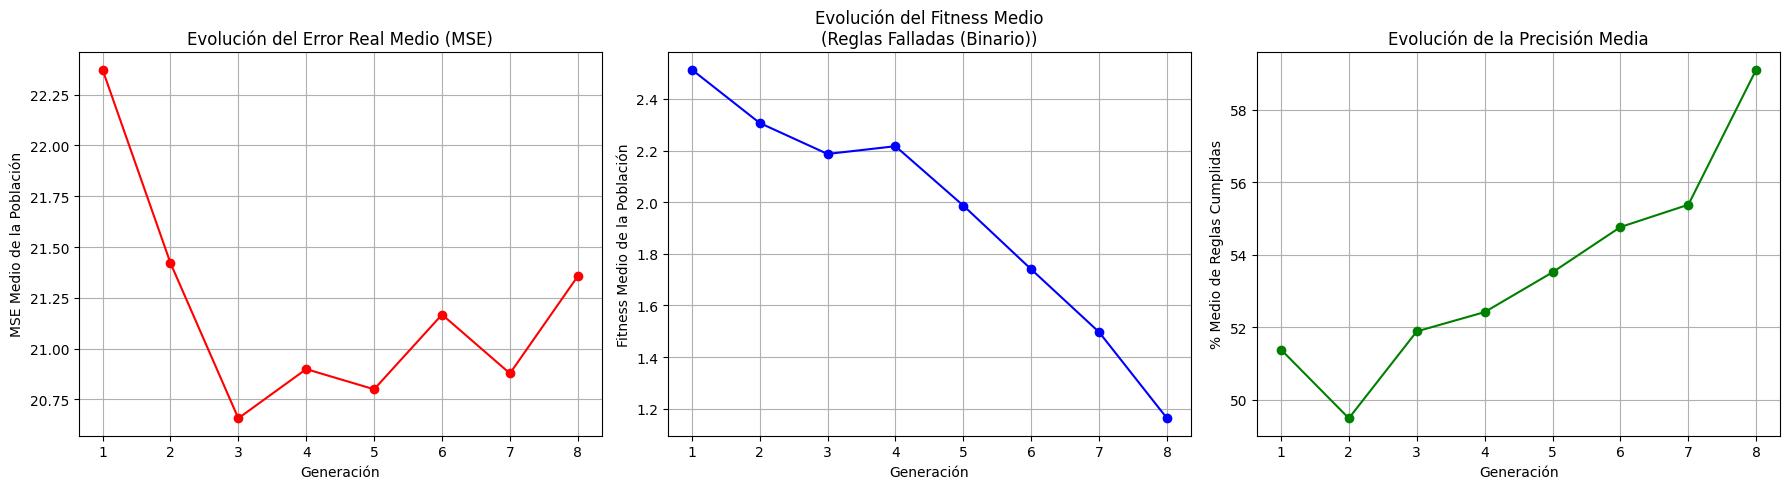

In [25]:
visualizador.plot_evolution_curves()

In [5]:
class RuleDecoder:
    """
    Clase auxiliar para decodificar y mostrar en formato legible humano 
    las reglas matemáticas optimizadas por la clase IDRecovery.
    """
    def __init__(self, net, rules):
        # Recibe la red de PySMILE y las reglas compiladas del optimizador
        self.net = net
        self.rules = rules

    def get_human_readable_rules(self):
        """
        Decodifica las reglas matemáticas internas y devuelve una lista 
        de diccionarios legibles para humanos.
        """
        readable_rules = []
        
        for r in self.rules:
            target_handle = self.net.get_node(r['node'])
            target_name = self.net.get_node_name(target_handle)
            action_name = self.net.get_outcome_id(target_handle, r['a_idx'])
            
            remainder = r['c_idx']
            context = {}
            
            for p in reversed(self.net.get_parents(target_handle)):
                n_outcomes = self.net.get_outcome_count(p)
                state_idx = remainder % n_outcomes
                remainder = remainder // n_outcomes
                
                parent_name = self.net.get_node_name(p)
                state_name = self.net.get_outcome_id(p, state_idx)
                
                context[parent_name] = state_name
            
            # Invertimos el orden para que visualmente vaya de padres a hijos
            context = {k: context[k] for k in reversed(list(context.keys()))}
            
            readable_rules.append({
                'Nodo_Decision': target_name,
                'Contexto': context,
                'Accion_Optima': action_name
            })
            
        return readable_rules

    def print_decoded_rules(self):
        """
        Imprime las reglas decodificadas por consola en un formato amigable.
        """
        rules = self.get_human_readable_rules()
        print("\n--- REGLAS DECODIFICADAS (HUMAN READABLE) ---")
        for i, rule in enumerate(rules):
            ctx_str = ", ".join([f"[{k}: '{v}']" for k, v in rule['Contexto'].items()])
            print(f"Regla {i+1} | SI {ctx_str}  --->  ENTONCES {rule['Nodo_Decision']} = '{rule['Accion_Optima']}'")

In [6]:
decoder = RuleDecoder(net=rec_model.net, rules=rec_model.all_rules)
decoder.print_decoded_rules()


--- REGLAS DECODIFICADAS (HUMAN READABLE) ---
Regla 1 | SI [PAIN: 'ABSENT'], [ANGIOGRAM: 'NEGATIVE'], [EARLYRESULTS: 'CoRem']  --->  ENTONCES HEARTPHARMA = 'NO'
Regla 2 | SI [PAIN: 'ABSENT'], [ANGIOGRAM: 'NEGATIVE'], [EARLYRESULTS: 'PaRem']  --->  ENTONCES HEARTPHARMA = 'YES'
Regla 3 | SI [PAIN: 'ABSENT'], [ANGIOGRAM: 'NEGATIVE'], [EARLYRESULTS: 'NoChng']  --->  ENTONCES HEARTPHARMA = 'YES'
Regla 4 | SI [PAIN: 'ABSENT'], [ANGIOGRAM: 'NEGATIVE'], [EARLYRESULTS: 'PrgrsvDisease']  --->  ENTONCES HEARTPHARMA = 'YES'
Regla 5 | SI [PAIN: 'ABSENT'], [ANGIOGRAM: 'POSITIVE'], [EARLYRESULTS: 'CoRem']  --->  ENTONCES HEARTPHARMA = 'NO'
Regla 6 | SI [PAIN: 'ABSENT'], [ANGIOGRAM: 'POSITIVE'], [EARLYRESULTS: 'PaRem']  --->  ENTONCES HEARTPHARMA = 'NO'
Regla 7 | SI [PAIN: 'ABSENT'], [ANGIOGRAM: 'POSITIVE'], [EARLYRESULTS: 'NoChng']  --->  ENTONCES HEARTPHARMA = 'NO'
Regla 8 | SI [PAIN: 'ABSENT'], [ANGIOGRAM: 'POSITIVE'], [EARLYRESULTS: 'PrgrsvDisease']  --->  ENTONCES HEARTPHARMA = 'NO'
Regla 9 | SI